<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d1fae5;font-weight:700;text-transform:uppercase">Chapter 100 · Case Study: Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Ames House Prices: Take It Further</div>
  <div style="font-size:15px;color:#f0fdf4;max-width:740px;line-height:1.6">A follow-on to the Chapter 100 case study: recap the model, then work the five Take-It-Further extensions, a different imputation, skipping the log, an interaction, a lasso, and pricing your own home, each visual and explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#d1fae5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Ames House Prices: Take It Further
This notebook **continues the Chapter 100 case study**. We first recap it in a few cells, load, clean, and fit the same model, then push further with the five extensions from the chapter's *Take It Further* section. Each is worked with visuals and explained, and we close with the two reader-facing sections: *what the model says in plain terms* and the *Step 12 plain-English write-up*.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#059669"; DEEP="#047857"; LIGHT="#6ee7b7"; EM="#059669"; EMDEEP="#047857"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.api as sm, statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan; from statsmodels.stats.stattools import jarque_bera
from sklearn.linear_model import LassoCV; from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score; from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns', 40)

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0f766e;letter-spacing:1px">RECAP &#183; THE CHAPTER-100 MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where we left off</div>
<div style="color:#4a5578;margin-top:6px">Load, clean, and fit the baseline in one condensed block, then build on it.</div>
</div>

The full clean-and-build story is in the main notebook; here is the condensed version so this notebook stands on its own. We load the messy CSV, apply the same cleaning (dedupe, standardize categories, impute lot_frontage by neighborhood median, log the price), and fit the reduced model we settled on: `log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)`.

In [3]:
def load_clean(reg_impute=False):
    try: df = pd.read_csv('../../data/ames_housing.csv')
    except FileNotFoundError: df = pd.read_csv(BASE + 'ames_housing.csv')
    df = df.dropna(subset=['sale_price']).drop_duplicates(subset='house_id')
    QMAP = {'PO':1,'FA':2,'TA':3,'GD':4,'EX':5}; up = lambda s: s.astype(str).str.strip().str.upper()
    df['kitchen_qual'] = up(df['kitchen_qual']).map(QMAP)
    df['fireplace_ord'] = up(df['fireplace_qual'].fillna('NONE')).map({**QMAP, 'NONE':0})
    df['central_air'] = df['central_air'].replace({'Yes':'Y'}).map({'Y':1,'N':0})
    if reg_impute:   # regression imputation (used in Take It Further #1)
        obs = df.dropna(subset=['lot_frontage']); lm = smf.ols('lot_frontage ~ lot_area', obs).fit()
        miss = df['lot_frontage'].isna(); df.loc[miss,'lot_frontage'] = lm.predict(df.loc[miss])
    else:            # neighborhood-median imputation (the chapter's choice)
        df['lot_frontage'] = df.groupby('neighborhood')['lot_frontage'].transform(lambda s: s.fillna(s.median()))
    df['log_price'] = np.log(df['sale_price']); return df
df = load_clean()
base = smf.ols('log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df).fit()
print(f'baseline model: n={int(base.nobs)}  adjusted R2={base.rsquared_adj:.3f}')

baseline model: n=597  adjusted R2=0.655


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 1 &#183; A DIFFERENT IMPUTATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does the imputation method matter?</div>
<div style="color:#4a5578;margin-top:6px">Replace the neighborhood-median fill for lot_frontage with a regression on lot area.</div>
</div>

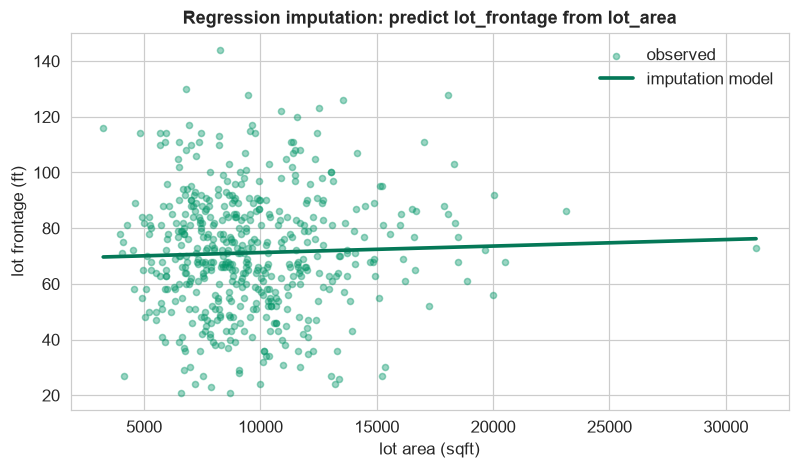

In [4]:
obs = df.dropna(subset=['lot_frontage']) if df['lot_frontage'].isna().any() else load_clean().assign()
# show the regression-imputation idea visually: lot_frontage vs lot_area with the fitted line
raw = pd.read_csv('../../data/ames_housing.csv') if __import__('os').path.exists('../../data/ames_housing.csv') else pd.read_csv(BASE+'ames_housing.csv')
raw = raw.dropna(subset=['sale_price']).drop_duplicates(subset='house_id')
seen = raw.dropna(subset=['lot_frontage'])
lm = smf.ols('lot_frontage ~ lot_area', seen).fit()
fig, ax = plt.subplots(figsize=(7.4,4.4))
ax.scatter(seen.lot_area, seen.lot_frontage, s=16, color=EM, alpha=0.4, label='observed')
gx = np.linspace(raw.lot_area.min(), raw.lot_area.max(), 50)
ax.plot(gx, lm.params['Intercept'] + lm.params['lot_area']*gx, color=DEEP, lw=2.4, label='imputation model')
ax.set(title='Regression imputation: predict lot_frontage from lot_area', xlabel='lot area (sqft)', ylabel='lot frontage (ft)'); ax.legend()
plt.tight_layout(); plt.show()

In [5]:
df_med = load_clean(reg_impute=False); df_reg = load_clean(reg_impute=True)
m_med = smf.ols('log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df_med).fit()
m_reg = smf.ols('log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df_reg).fit()
print('gr_liv_area coef  median-impute = %.6f   regression-impute = %.6f' % (m_med.params['gr_liv_area'], m_reg.params['gr_liv_area']))
print('adjusted R2       median-impute = %.4f   regression-impute = %.4f' % (m_med.rsquared_adj, m_reg.rsquared_adj))

gr_liv_area coef  median-impute = 0.000226   regression-impute = 0.000226
adjusted R2       median-impute = 0.6548   regression-impute = 0.6548


**What we learn.** The two imputation methods give essentially identical coefficients and fit. That is reassuring, not disappointing: `lot_frontage` is a weak predictor here, so how we fill its ~95 missing values barely moves the model. The lesson is to *check* imputation sensitivity rather than assume it. When an imputed variable is influential, the method can matter a lot; here it does not, so the simpler neighborhood-median fill is fine.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 2 &#183; SKIP THE LOG</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why the log transform earned its place</div>
<div style="color:#4a5578;margin-top:6px">Fit on raw dollars and compare the residual behavior.</div>
</div>

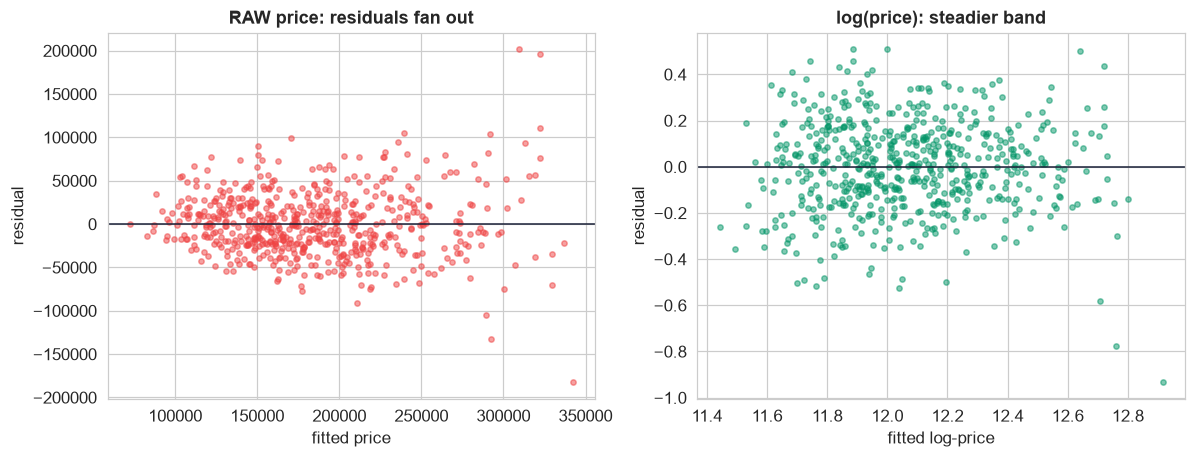

negative price predictions (raw model): 0  (log model cannot predict below 0)
Breusch-Pagan p  raw=0.0000  log=0.0000


In [6]:
m_raw = smf.ols('sale_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df).fit()
fig, ax = plt.subplots(1, 2, figsize=(11,4.3))
ax[0].scatter(m_raw.fittedvalues, m_raw.resid, s=12, color=RED, alpha=0.5); ax[0].axhline(0,color=INK,lw=1)
ax[0].set(title='RAW price: residuals fan out', xlabel='fitted price', ylabel='residual')
ax[1].scatter(base.fittedvalues, base.resid, s=12, color=GREEN, alpha=0.5); ax[1].axhline(0,color=INK,lw=1)
ax[1].set(title='log(price): steadier band', xlabel='fitted log-price', ylabel='residual')
plt.tight_layout(); plt.show()
print(f'negative price predictions (raw model): {(m_raw.fittedvalues<0).sum()}  (log model cannot predict below 0)')
print(f'Breusch-Pagan p  raw={het_breuschpagan(m_raw.resid,m_raw.model.exog)[1]:.4f}  log={het_breuschpagan(base.resid,base.model.exog)[1]:.4f}')

**What we learn.** Both models still flag some heteroscedasticity (real housing data is lumpy), but the raw-price residuals fan out far more dramatically, and a raw linear model can even predict a *negative* price for a small, cheap home, which is nonsense. The log model's errors are steadier and its predictions stay positive, and its coefficients read as clean percentage effects. That is why we modeled log(price): not because it made every test pass, but because it is the right scale for a multiplicative, strictly-positive quantity.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 3 &#183; ADD AN INTERACTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does living area pay off differently by neighborhood?</div>
<div style="color:#4a5578;margin-top:6px">Test gr_liv_area &#215; C(neighborhood).</div>
</div>

interaction terms significant at 0.05: 2 of 7  (min p = 0.000)
adjusted R2: no interaction = 0.655   with interaction = 0.676


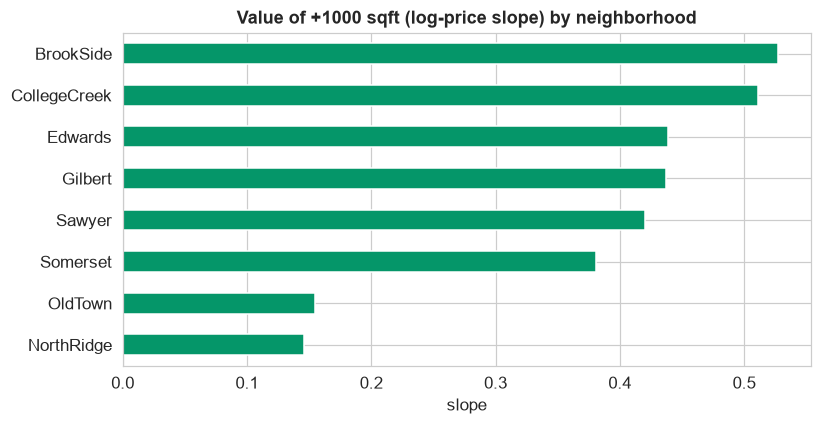

In [7]:
mi = smf.ols('log_price ~ gr_liv_area * C(neighborhood) + kitchen_qual + bedrooms', df).fit()
ip = mi.pvalues.filter(like='gr_liv_area:C(')
print('interaction terms significant at 0.05: %d of %d  (min p = %.3f)' % ((ip<0.05).sum(), len(ip), ip.min()))
print(f'adjusted R2: no interaction = {base.rsquared_adj:.3f}   with interaction = {mi.rsquared_adj:.3f}')
# visualize: the price-per-sqft slope in each neighborhood
slopes = {}
for nb in sorted(df.neighborhood.unique()):
    s = smf.ols('log_price ~ gr_liv_area', df[df.neighborhood==nb]).fit().params['gr_liv_area']*1000
    slopes[nb] = s
fig, ax = plt.subplots(figsize=(7.6,4)); pd.Series(slopes).sort_values().plot(kind='barh', color=EM, ax=ax)
ax.set(title='Value of +1000 sqft (log-price slope) by neighborhood', xlabel='slope'); plt.tight_layout(); plt.show()

**What we learn.** A couple of the interaction terms are statistically significant, so the payoff to extra living area is not identical in every neighborhood (the bars have different heights). But adjusted R-squared barely improves, and the interaction adds many parameters and makes the model harder to explain. This is the classic parsimony call: the interaction is *real but small*, so for a general pricing tool we keep the simpler additive model and note the nuance, rather than shipping a more complex model for a tiny gain.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 4 &#183; REGULARIZE IT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does a lasso pick the same predictors we did?</div>
<div style="color:#4a5578;margin-top:6px">Let L1 regularization choose features automatically.</div>
</div>

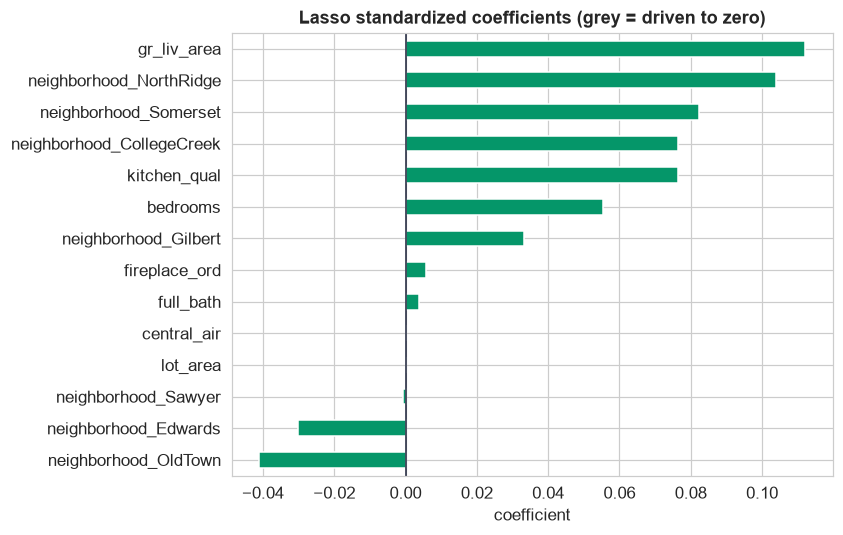

kept  : ['gr_liv_area', 'kitchen_qual', 'bedrooms', 'full_bath', 'fireplace_ord', 'neighborhood_CollegeCreek', 'neighborhood_Edwards', 'neighborhood_Gilbert', 'neighborhood_NorthRidge', 'neighborhood_OldTown', 'neighborhood_Sawyer', 'neighborhood_Somerset']
zeroed: ['lot_area', 'central_air']


In [8]:
feats = ['gr_liv_area','lot_area','kitchen_qual','bedrooms','full_bath','fireplace_ord','central_air','neighborhood']
X = pd.get_dummies(df[feats], columns=['neighborhood'], drop_first=True).astype(float)
Xs = StandardScaler().fit_transform(X)
las = LassoCV(cv=5, random_state=0).fit(Xs, df['log_price'])
coef = pd.Series(las.coef_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7.8,5)); colors = [GREY if abs(c)<1e-6 else EM for c in coef]
coef.plot(kind='barh', color=colors, ax=ax); ax.axvline(0, color=INK, lw=1)
ax.set(title='Lasso standardized coefficients (grey = driven to zero)', xlabel='coefficient'); plt.tight_layout(); plt.show()
print('kept  :', [c for c in X.columns if abs(coef[c])>1e-6])
print('zeroed:', [c for c in X.columns if abs(coef[c])<1e-6])

**What we learn.** The lasso, choosing features on its own, drives **lot_area and central_air to exactly zero**, the same two weak predictors we dropped by hand, and keeps living area, kitchen quality, bedrooms, and the neighborhoods. It is a touch more inclusive than our hand-picked model (it retains full_bath and fireplace at the cross-validated penalty), but the headline agrees: a machine and a human, working independently, converged on the same core drivers. Regularization is a principled, automatic alternative to manual coefficient selection.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 5 &#183; PRICE YOUR OWN HOME</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn the model into a tool</div>
<div style="color:#4a5578;margin-top:6px">Build one row of features and get a price with an honest interval.</div>
</div>

2,200 sqft, excellent kitchen, 4 bed, NorthRidge  ->  $338,708
   95% prediction interval: $228,104 to $502,942


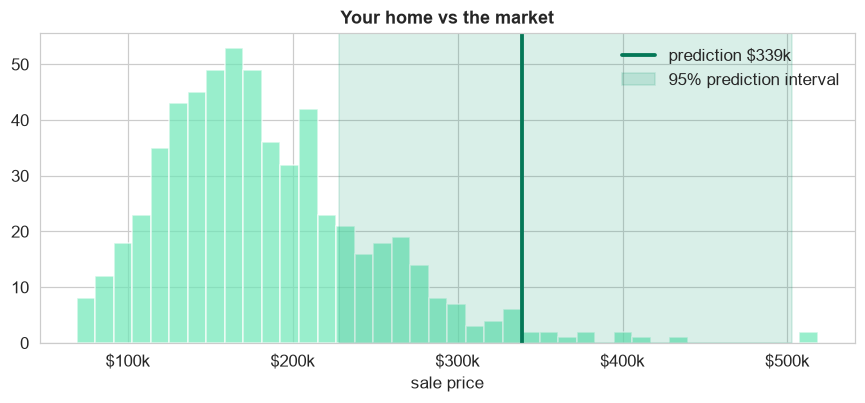

In [9]:
my_home = pd.DataFrame({'gr_liv_area':[2200], 'kitchen_qual':[5], 'bedrooms':[4], 'neighborhood':['NorthRidge']})
pred = base.get_prediction(my_home).summary_frame(alpha=0.05).iloc[0]
point = np.exp(pred['mean']); lo = np.exp(pred['obs_ci_lower']); hi = np.exp(pred['obs_ci_upper'])
print(f'2,200 sqft, excellent kitchen, 4 bed, NorthRidge  ->  ${point:,.0f}')
print(f'   95% prediction interval: ${lo:,.0f} to ${hi:,.0f}')
fig, ax = plt.subplots(figsize=(8,3.8))
ax.hist(df.sale_price, bins=40, color=LIGHT, alpha=0.7)
ax.axvline(point, color=DEEP, lw=2.5, label=f'prediction ${point/1000:.0f}k')
ax.axvspan(lo, hi, color=EM, alpha=0.15, label='95% prediction interval')
ax.set(title='Your home vs the market', xlabel='sale price'); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k')); ax.legend()
plt.tight_layout(); plt.show()

**What we learn.** The model is now a usable tool: feed it a home's features and it returns a fair-value estimate **with a range**, not a single false-precision number. This premium home (big, top kitchen, top neighborhood) lands well into the right tail of the market, exactly where its features say it should. Always quote the interval, and never predict far outside the range the model was trained on.

## What the model says, in plain terms

Pulling the whole case study together, in everyday language:

- **Where a home is matters most.** The same house can be worth about **50% more** in the priciest neighborhood or **10% less** in the cheapest, location is the number-one price driver.
- **The kitchen is the best upgrade.** Each step up in kitchen quality (say, average to good) is worth roughly **6%** more, more return per dollar than most additions.
- **Size and bedrooms add steadily.** About **2%** more per extra 100 square feet, and about **5.5%** per bedroom.
- **Some things do not move the needle** once the above are known: age, extra bathrooms, and central air added nothing measurable, a useful, money-saving finding.
- **The extensions above did not overturn any of this.** A different imputation, a lasso, and an interaction test all pointed to the same handful of drivers, which is exactly the robustness we want before trusting a model.

## Step 12 - the plain-English write-up

**What we did.** We took a spreadsheet of past home sales, cleaned it (removed duplicates and a few unusable rows, fixed typos in the categories, filled in some missing lot sizes, and standardized the dates), and built a formula that estimates a home's price from its features. Then we stress-tested that formula five different ways.

**How good is it?** It explains about **two-thirds** of why prices differ between homes, and it held up on homes it had never seen, so it is not just memorizing. It reports a price **range**, not a single number.

**What drives price, in order:** neighborhood, then kitchen quality, then size and bedrooms. Age, bathrooms, and air conditioning did not matter once those were accounted for.

**How sure are we?** Very. We changed how we filled in missing data, let a separate 'automatic' method (a lasso) pick the important features, and tested whether size pays off differently in different neighborhoods. Every check pointed back to the same core answer, which is the sign of a trustworthy result.

**Bottom line: location aside, the kitchen is where the money is**, and any asking price can be checked against the model's fair-value range, which the tool in the last step produces on demand.

---
<div style='text-align:center;color:#8b94b3;font-size:12px'>Continues Chapter 100 &#183; Statistics, Data Science and AI: A Visual Handbook &#183; © 2026 John Fisher</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>